# gCRL-VAE — Norman 2019 experiment comparison

Loads training histories and prediction metrics from three notebook runs and compares them side-by-side:

| Key | Data | Loss weights |
|---|---|---|
| `40pct_gamma0p9` | 40 % GRN, gamma=0.9 | balanced (alpha_mmd=1, beta_kld=50) |
| `100pct_gamma1p1` | 100 % GRN, gamma=1.1 | balanced (alpha_mmd=1, beta_kld=50) |
| `100pct_gamma1p1_boost_recon` | 100 % GRN, gamma=1.1 | boosted recon (alpha_mmd=10, beta_kld=1) |

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE = "../../results/real/Norman2019"

# Each entry: (display label, result directory prefix)
EXPERIMENTS = [
    ("40pct γ0.9\n(balanced)",         "vae_40pct_gamma0p9"),
    ("100pct γ1.1\n(balanced)",        "vae_100pct_gamma1p1"),
    ("100pct γ1.1\n(boost recon)",     "vae_100pct_gamma1p1_boost_recon"),
]

# Sub-models within each experiment
SUBMODELS = [
    ("gCRL-VAE",       ""),
    ("CMVAE-full",     "_cmvae_full"),
    ("CMVAE-comp",     "_cmvae_comp"),
]

## 1. Load data

In [3]:
def load_history(prefix, suffix):
    path = f"{BASE}/{prefix}{suffix}/training_history.json"
    with open(path) as f:
        return pd.DataFrame(json.load(f))

def load_metrics(prefix, suffix):
    path = f"{BASE}/{prefix}{suffix}/prediction_metrics.csv"
    return pd.read_csv(path)

histories = {}
metrics   = {}

for exp_label, prefix in EXPERIMENTS:
    for sub_label, suffix in SUBMODELS:
        key = (exp_label, sub_label)
        histories[key] = load_history(prefix, suffix)
        metrics[key]   = load_metrics(prefix, suffix)
        print(f"Loaded {prefix}{suffix}")

Loaded vae_40pct_gamma0p9
Loaded vae_40pct_gamma0p9_cmvae_full
Loaded vae_40pct_gamma0p9_cmvae_comp
Loaded vae_100pct_gamma1p1
Loaded vae_100pct_gamma1p1_cmvae_full
Loaded vae_100pct_gamma1p1_cmvae_comp
Loaded vae_100pct_gamma1p1_boost_recon
Loaded vae_100pct_gamma1p1_boost_recon_cmvae_full
Loaded vae_100pct_gamma1p1_boost_recon_cmvae_comp


## 2. Training curves

Rows = experiments, columns = loss components.

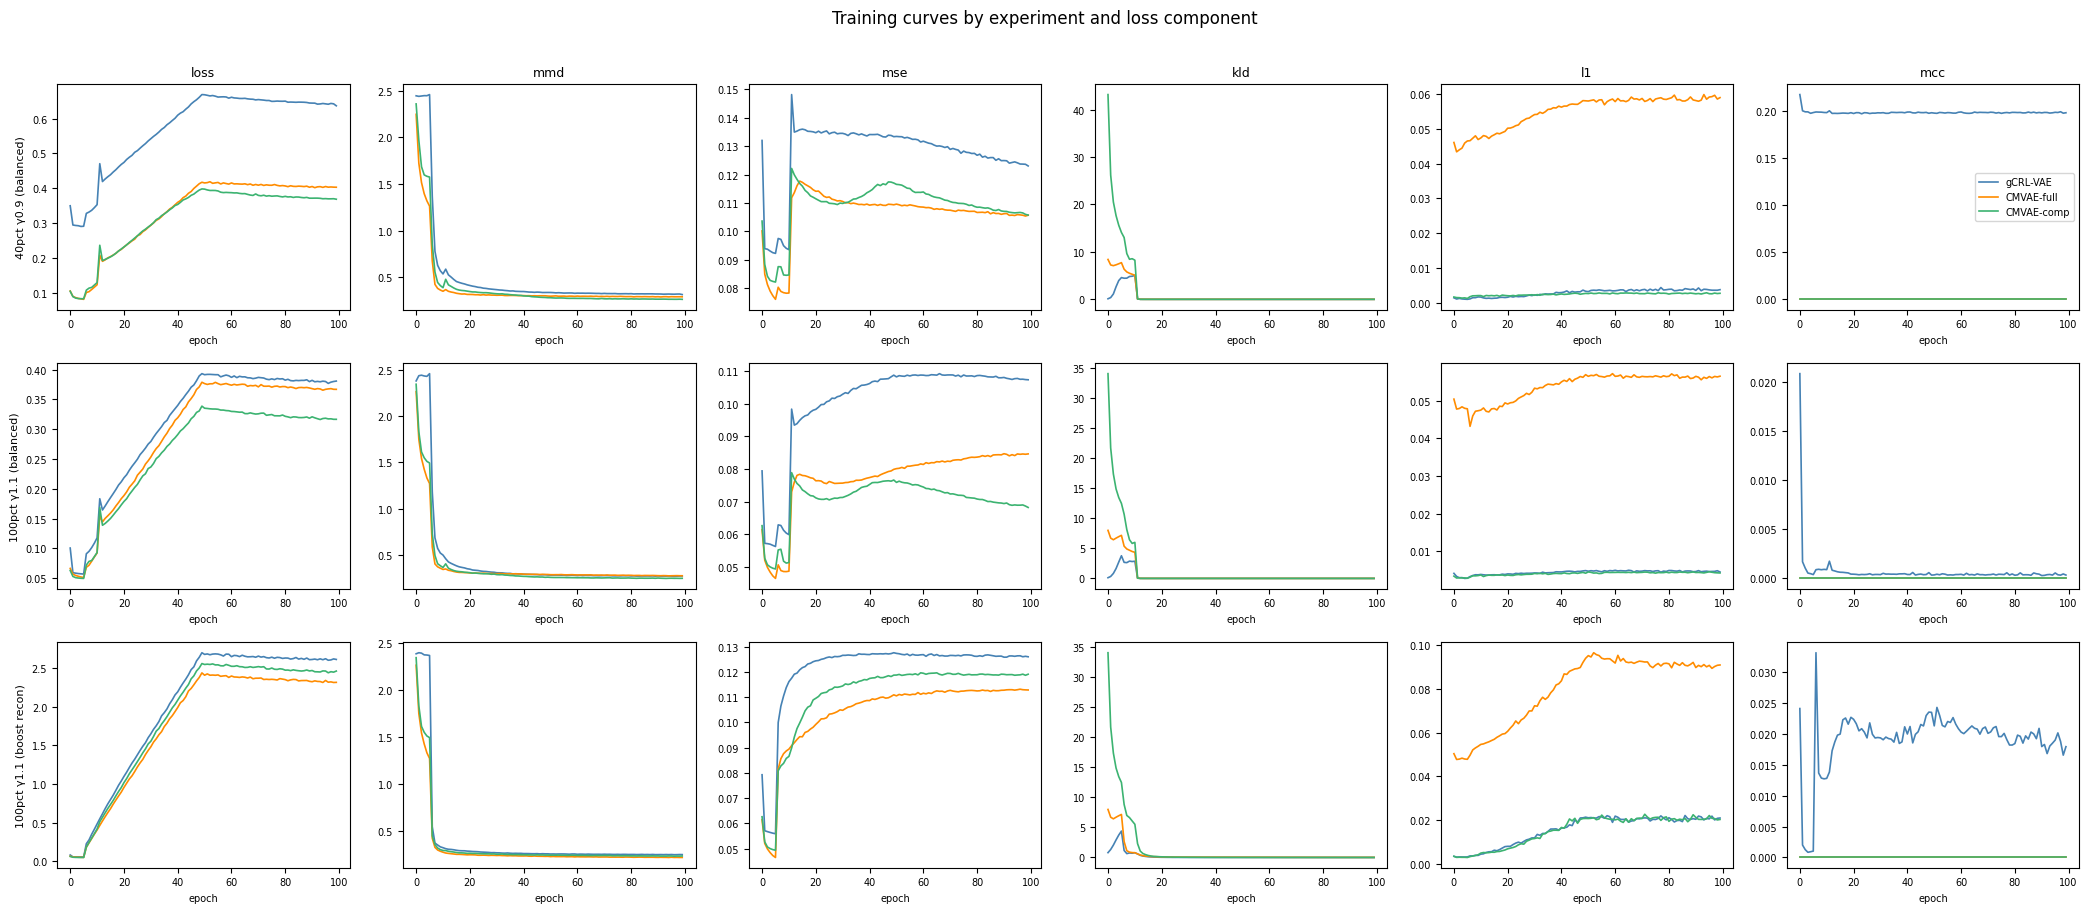

In [4]:
LOSS_COLS = ["loss", "mmd", "mse", "kld", "l1", "mcc"]
colors    = {"gCRL-VAE": "steelblue", "CMVAE-full": "darkorange", "CMVAE-comp": "mediumseagreen"}

n_exp  = len(EXPERIMENTS)
n_cols = len(LOSS_COLS)

fig, axes = plt.subplots(n_exp, n_cols, figsize=(3.5 * n_cols, 3 * n_exp), squeeze=False)

for row, (exp_label, prefix) in enumerate(EXPERIMENTS):
    for col, lc in enumerate(LOSS_COLS):
        ax = axes[row, col]
        for sub_label, suffix in SUBMODELS:
            df = histories[(exp_label, sub_label)]
            if lc in df.columns:
                ax.plot(df["epoch"], df[lc], label=sub_label,
                        color=colors[sub_label], linewidth=1.2)
        if row == 0:
            ax.set_title(lc, fontsize=9)
        if col == 0:
            ax.set_ylabel(exp_label.replace("\n", " "), fontsize=8)
        ax.set_xlabel("epoch", fontsize=7)
        ax.tick_params(labelsize=7)
        if row == 0 and col == n_cols - 1:
            ax.legend(fontsize=7)

plt.suptitle("Training curves by experiment and loss component", y=1.01)
plt.tight_layout()
plt.show()

## 3. Prediction performance summary

Median centroid distance and RMSE across all double-perturbation conditions.

In [5]:
rows = []
for exp_label, prefix in EXPERIMENTS:
    for sub_label, suffix in SUBMODELS:
        df = metrics[(exp_label, sub_label)]
        for metric_name in df["metric_name"].unique():
            for method in df["method"].unique():
                val = df.loc[
                    (df["metric_name"] == metric_name) & (df["method"] == method),
                    "metric_value"
                ].median()
                rows.append({
                    "experiment": exp_label.replace("\n", " "),
                    "model":      sub_label,
                    "metric":     metric_name,
                    "method":     method,
                    "median":     val,
                })

summary = pd.DataFrame(rows)
pivot = summary.pivot_table(
    index=["metric", "method"],
    columns=["experiment", "model"],
    values="median",
).round(4)
print("Median metrics across all double-perturbation conditions:")
pivot

Median metrics across all double-perturbation conditions:


experiment                         100pct γ1.1 (balanced)                      \
model                                          CMVAE-comp CMVAE-full gCRL-VAE   
metric            method                                                        
centroid_distance actual                          15.7144     9.8899   9.0661   
                  perfect_baseline                 1.8756     1.8756   1.8756   
                  worst_case                       5.4667     5.4667   5.4667   
rmse              actual                           0.3023     0.1902   0.1744   
                  perfect_baseline                 0.0361     0.0361   0.0361   
                  worst_case                       0.1051     0.1051   0.1051   

experiment                         100pct γ1.1 (boost recon)             \
model                                             CMVAE-comp CMVAE-full   
metric            method                                                  
centroid_distance actual                              7.7624     7.6317   
                  perfect_baseline                    1.8756     1.8756   
                  worst_case                          5.4667     5.4667   
rmse              actual                              0.1493     0.1468   
                  perfect_baseline                    0.0361     0.0361   
                  worst_case                          0.1051     0.1051   

experiment                                  40pct γ0.9 (balanced)             \
model                              gCRL-VAE            CMVAE-comp CMVAE-full   
metric            method                                                       
centroid_distance actual             6.7711               20.1892     6.2240   
                  perfect_baseline   1.8756                1.8720     1.8720   
                  worst_case         5.4667                5.4642     5.4642   
rmse              actual             0.1302                0.4982     0.1536   
                  perfect_baseline   0.0361                0.0462     0.0462   
                  worst_case         0.1051                0.1348     0.1348   

experiment                                   
model                              gCRL-VAE  
metric            method                     
centroid_distance actual            12.9920  
                  perfect_baseline   1.8720  
                  worst_case         5.4642  
rmse              actual             0.3206  
                  perfect_baseline   0.0462  
                  worst_case         0.1348

## 4. Bar chart: median centroid distance by model and experiment

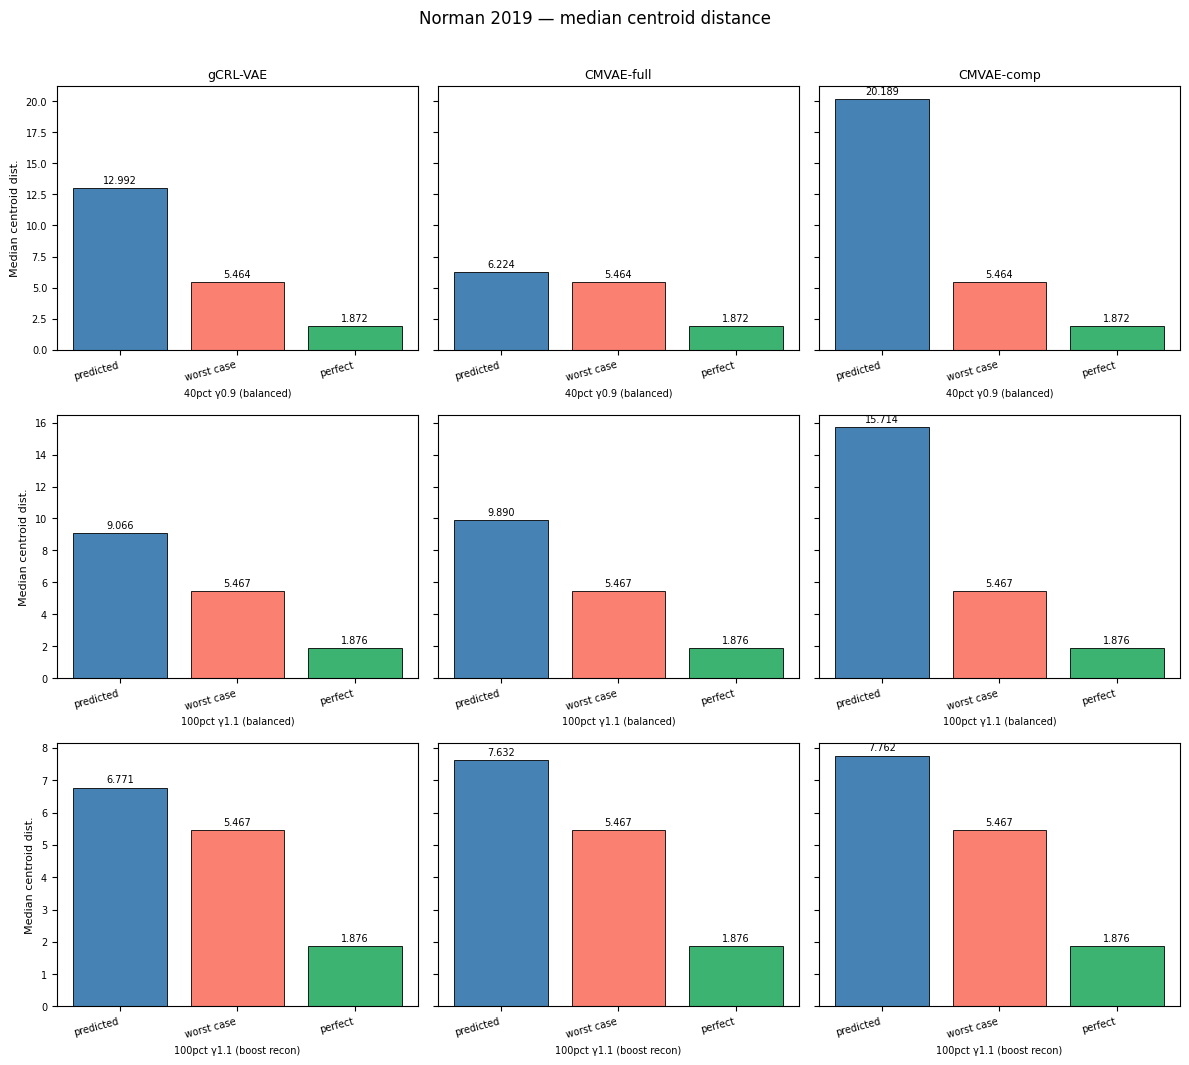

In [6]:
methods_order = ["actual", "worst_case", "perfect_baseline"]
method_colors = {"actual": "steelblue", "worst_case": "salmon", "perfect_baseline": "mediumseagreen"}
sub_labels    = [s for s, _ in SUBMODELS]

cd = summary[(summary["metric"] == "centroid_distance")]

n_exp  = len(EXPERIMENTS)
n_sub  = len(SUBMODELS)
fig, axes = plt.subplots(n_exp, n_sub, figsize=(4 * n_sub, 3.5 * n_exp),
                          sharey="row", squeeze=False)

for row, (exp_label, _) in enumerate(EXPERIMENTS):
    exp_str = exp_label.replace("\n", " ")
    for col, (sub_label, _) in enumerate(SUBMODELS):
        ax = axes[row, col]
        sub_df = cd[(cd["experiment"] == exp_str) & (cd["model"] == sub_label)]
        vals = sub_df.set_index("method")["median"].reindex(methods_order)
        bars = ax.bar(
            range(len(methods_order)), vals.values,
            color=[method_colors[m] for m in methods_order],
            edgecolor="k", linewidth=0.6,
        )
        ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=7)
        ax.set_xticks(range(len(methods_order)))
        ax.set_xticklabels(["predicted", "worst case", "perfect"], rotation=15, ha="right", fontsize=7)
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.set_ylabel("Median centroid dist.", fontsize=8)
        if row == 0:
            ax.set_title(sub_label, fontsize=9)
        ax.set_xlabel(exp_label.replace("\n", " "), fontsize=7)

plt.suptitle("Norman 2019 — median centroid distance", y=1.01)
plt.tight_layout()
plt.show()